In [1]:
import torch, json, glob, os
import numpy as np
import json

from models import EfficientNet_pretrained

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

/home/ceib/jaalzate/BIMCV-Prostate-Classification/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device

device(type='cuda', index=1)

# Ensemble inference (averaging logits) + optional weighting

In [1]:
def load_model(weight_path):
    state = torch.load(weight_path, map_location="cpu")["state_dict"]
    first_key = next(iter(state.keys()), "")
    if isinstance(first_key, str) and first_key.startswith("model."):
        model = EfficientNet_pretrained(
            model_name="efficientnet-b7",
            n_classes=2,
            in_channels_eff=3,
            pretrained_weights_path=None
        )
        
        print(state.keys())
        model.load_state_dict(state)
        
    else:
        model = EfficientNet_pretrained(
            model_name="efficientnet-b7",
            n_classes=2,
            in_channels_eff=3,
            pretrained_weights_path=weight_path
        )

    model.to(device).eval()
    
    return model


def load_fold_models(root_pattern):
    # root_pattern e.g. ".../logs/classification/Prostate_Picai_efficientnetb7/*/models/best-model-weights.pth"
    paths = sorted(glob.glob(root_pattern))
    models = [load_model(p) for p in paths]
    return models, paths

@torch.no_grad()
def ensemble_logits(models, dataloader, weights=None, temperatures=None):
    """
    weights: list len=M (sums to 1) or None
    temperatures: list len=M (floats) or None; divides logits before combining
    Returns stacked logits (N,2) and probs (N,2)
    """
    if weights is None:
        weights = [1.0/len(models)]*len(models)
    if temperatures is None:
        temperatures = [1.0]*len(models)

    all_logits = []
    for batch in dataloader:
        x = batch["image"].to(device)
        batch_logits = torch.zeros(x.size(0), 2, device=device)
        for m, w, T in zip(models, weights, temperatures):
            l = m(x) / T
            batch_logits += w * l
        all_logits.append(batch_logits.cpu())
    logits = torch.cat(all_logits, dim=0)
    probs = torch.softmax(logits, dim=1)
    return logits.numpy(), probs.numpy()

NameError: name 'torch' is not defined

In [4]:
from bimcv_prostate.data.dataloaders import ProstateImageDataLoader as Dataloader
from models import EfficientNet_pretrained
import torch
import torchmetrics
import torch.nn.functional as F
import pandas as pd
from monai import transforms
from torch import as_tensor
from torch.nn.functional import one_hot
from monai.data import CacheDataset, DataLoader
from models import EfficientNet_pretrained

In [5]:
# --- Configuration ---
fold_model_pattern = "logs/classification/Prostate_Picai_efficientnetb7/18-Aug-2025-10:41:51/models/*/best-model-weights.pth"
cross_val_results_path = "logs/classification/Prostate_Picai_efficientnetb7/18-Aug-2025-10:41:51/cross_val_results.json"
output_json = "outputs/results/ensemble_BIMCV_test_results.json"
use_f1_weights = True          # set False for uniform
apply_platt_after_ensemble = True  # global calibration
threshold_mode = "youden"       # "youden" | "f1" | float value

from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc, classification_report, confusion_matrix, f1_score
import numpy as np, json, os, torch

In [6]:
# df = pd.read_csv("Files/data_with_splits_dep_disjoint.csv")

df = pd.read_csv("Files/data_noder.csv")

df_test = df[df["split"]=="test"]
df_test=df_test.dropna(subset=['PSA']).reset_index(drop=True) # remove rows with missing PSA values

df_test['image_t2'] = df_test['image_t2'].apply(lambda x: x.replace("ceib/", ""))
df_test['image_adc'] = df_test['image_adc'].apply(lambda x: x.replace("ceib/", ""))
df_test['image_dwi'] = df_test['image_dwi'].apply(lambda x: x.replace("ceib/", ""))

df_test['image_t2'] = df_test['image_t2'].apply(lambda x: x.replace("prueba/p0052021_reborn/", "p0052021/"))
df_test['image_adc'] = df_test['image_adc'].apply(lambda x: x.replace("prueba/p0052021_reborn/", "p0052021/"))
df_test['image_dwi'] = df_test['image_dwi'].apply(lambda x: x.replace("prueba/p0052021_reborn/", "p0052021/"))

df_test['image_t2'] = df_test['image_t2'].apply(lambda x: x.replace("prueba/", ""))
df_test['image_adc'] = df_test['image_adc'].apply(lambda x: x.replace("prueba/", ""))
df_test['image_dwi'] = df_test['image_dwi'].apply(lambda x: x.replace("prueba/", ""))


img_columns=["t2", "adc", "dwi"]
input_shape = (128, 128, 32)
val_transforms = transforms.Compose([
        transforms.LoadImaged(keys=img_columns, image_only=True,ensure_channel_first=True),
        transforms.ResampleToMatchd(
            keys=["adc", "dwi"],
            key_dst="t2",
            mode=("bilinear", "bilinear"),
        ), # Resample images to t2 dimension
        transforms.SplitDimd(
            keys=["dwi"],
            keepdim=True,
        ), 
        transforms.Resized(
            keys=['t2','dwi_0','adc'],
            spatial_size=input_shape,
            mode=("trilinear", "trilinear", "trilinear"),
        ),
        transforms.ScaleIntensityRangePercentilesd(keys=['adc'], lower=5, upper=99.5,b_min=0.0, b_max=1.0,clip=True),
        transforms.ScaleIntensityd(keys=['t2','dwi_0'], minv=0.0, maxv=1.0, allow_missing_keys=True),
        transforms.ConcatItemsd(keys=['t2','dwi_0','adc'], name="image", dim=0),
        transforms.SelectItemsd(keys=["image", "label"])
        ])

data = [
            {"t2": t2, "adc": adc, "dwi": dwi, "label": label}
            for t2, adc, dwi, label in zip(
                df_test["image_t2"].values,
                df_test["image_adc"].values,
                df_test["image_dwi"].values,
                one_hot(as_tensor(df_test["csPC"].values, dtype=int)).float(),
            )
        ]


dataset = CacheDataset(data=data, transform=val_transforms, num_workers=7)
test_dataloader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=7)

Loading dataset: 100%|██████████| 446/446 [02:43<00:00,  2.73it/s]


In [7]:
df_test

,Unnamed: 0,subject,session,image_t2,image_dwi,image_adc,dep,ED,AF,TB,...,PSA,VP,PIR,csPC,F_nacimiento,F_RM,partition,Derivative,VP_segmentation,split
0,0,sub-002726,ses-004030,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,20.0,75.0,NaN,NaN,...,6.70,NaN,2.0,0.0,1944-07-28,2020-05-02,train,False,NaN,test
1,1,sub-003019,ses-003234,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,20.0,70.0,NaN,NaN,...,19.50,NaN,5.0,0.0,1941-11-29,2012-01-31,train,False,NaN,test
2,2,sub-008321,ses-009264,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,20.0,69.0,NaN,NaN,...,6.47,NaN,3.0,1.0,1944-04-16,2013-07-28,train,False,NaN,test
3,3,sub-008321,ses-009264,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,20.0,69.0,NaN,NaN,...,6.47,NaN,3.0,1.0,1944-04-16,2013-07-28,train,False,NaN,test
4,4,sub-003327,ses-003551,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,20.0,57.0,NaN,NaN,...,12.60,NaN,3.0,0.0,1959-01-05,2016-12-05,train,False,NaN,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441,572,sub-001786,ses-001934,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,21.0,67.0,NaN,NaN,...,6.24,NaN,NaN,0.0,1941-12-03,2009-10-10,train,False,NaN,test
442,573,sub-002632,ses-007722,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,21.0,64.0,NaN,NaN,...,8.18,57.0492,NaN,1.0,1951-05-09,2015-10-26,train,False,NaN,test
443,574,sub-002632,ses-007722,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,21.0,64.0,NaN,NaN,...,8.18,57.0492,NaN,1.0,1951-05-09,2015-10-26,train,False,NaN,test
444,579,sub-001432,ses-001546,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,21.0,71.0,NaN,NaN,...,8.32,NaN,NaN,1.0,1936-04-15,2007-06-21,train,False,NaN,test


In [8]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 446 entries, 0 to 445
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       446 non-null    int64  
 1   subject          446 non-null    object 
 2   session          446 non-null    object 
 3   image_t2         446 non-null    object 
 4   image_dwi        446 non-null    object 
 5   image_adc        446 non-null    object 
 6   dep              446 non-null    float64
 7   ED               446 non-null    float64
 8   AF               4 non-null      float64
 9   TB               11 non-null     float64
 10  TR               0 non-null      float64
 11  PSA              446 non-null    float64
 12  VP               162 non-null    float64
 13  PIR              124 non-null    float64
 14  csPC             446 non-null    float64
 15  F_nacimiento     446 non-null    object 
 16  F_RM             446 non-null    object 
 17  partition       

In [ ]:
model_paths = [
    #'averaged_pretrained_backbone.pt'
    # 'logs/classification/best_model_bimcv/models/best-model-weights.pth',
    # 'logs/classification/Prostate_BIMCV/20-Aug-2025-12:11:05/models/best-checkpoint.pth',
    'logs/classification/Prostate_BIMCV/02-Sep-2025-16:24:58/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/03-Sep-2025-12:27:57/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/04-Sep-2025-08:50:36/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/05-Sep-2025-08:55:26/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/07-Sep-2025-19:13:33/models/best-model-weights.pth'
]

model_paths_noder = [
    "logs/classification/Prostate_BIMCV_noDerivatives/08-Sep-2025-17:42:38/models/best-model-weights.pth",
    "logs/classification/Prostate_BIMCV_noDerivatives/09-Sep-2025-08:52:30/models/best-model-weights.pth",
    "logs/classification/Prostate_BIMCV_noDerivatives/10-Sep-2025-08:47:09/models/best-model-weights.pth",
    "logs/classification/Prostate_BIMCV_noDerivatives/11-Sep-2025-08:50:30/models/best-model-weights.pth",
    "logs/classification/Prostate_BIMCV_noDerivatives/12-Sep-2025-08:45:05/models/best-model-weights.pth"
]


models = [load_model(p) for p in model_paths]


odict_keys(['model._conv_stem.weight', 'model._bn0.weight', 'model._bn0.bias', 'model._bn0.running_mean', 'model._bn0.running_var', 'model._bn0.num_batches_tracked', 'model._blocks.0.0._depthwise_conv.weight', 'model._blocks.0.0._bn1.weight', 'model._blocks.0.0._bn1.bias', 'model._blocks.0.0._bn1.running_mean', 'model._blocks.0.0._bn1.running_var', 'model._blocks.0.0._bn1.num_batches_tracked', 'model._blocks.0.0._se_reduce.weight', 'model._blocks.0.0._se_reduce.bias', 'model._blocks.0.0._se_expand.weight', 'model._blocks.0.0._se_expand.bias', 'model._blocks.0.0._project_conv.weight', 'model._blocks.0.0._bn2.weight', 'model._blocks.0.0._bn2.bias', 'model._blocks.0.0._bn2.running_mean', 'model._blocks.0.0._bn2.running_var', 'model._blocks.0.0._bn2.num_batches_tracked', 'model._blocks.0.1._depthwise_conv.weight', 'model._blocks.0.1._bn1.weight', 'model._blocks.0.1._bn1.bias', 'model._blocks.0.1._bn1.running_mean', 'model._blocks.0.1._bn1.running_var', 'model._blocks.0.1._bn1.num_batches_t

In [12]:
# --- Derive per-fold weights from cross_val_results.json (expects per-fold dicts with Val ROC AUC / or similar) ---
def extract_f1_weights(json_path):
    with open(json_path) as f:
        data = json.load(f)
    f1s = []
    keys = sorted(data.keys())  # fold order
    for k in keys:
        if 'Fold' in k:
            fold_dict = data[k]
            print(f"Fold {k}: {fold_dict['Test Metrics']}")
            f1s.append(fold_dict['Test Metrics']['f1'])
            print(f"Fold {k} F1: {fold_dict['Test Metrics']['f1']}")
            print(f1s)
    f1s = np.array(f1s, dtype=float)
    if (f1s <= 0).any():
        raise ValueError("F1 scores must be positive for weighting.")
    weights = f1s / f1s.sum()
    return weights.tolist()

# if use_f1_weights:
#     try:
#         weights = extract_f1_weights(cross_val_results_path)
#     except Exception as e:
#         print(f"Falling back to uniform weights ({e})")
#         weights = None
# else:
#     weights = None
# print("Weights:", weights)
weights = None

# --- Run ensemble (no calibration yet) ---
raw_logits, raw_probs = ensemble_logits(models, test_dataloader, weights=weights)
p_pos = raw_probs[:,1]

In [13]:
# --- Threshold selection ---
def pick_threshold(y_true, p_pos, mode="youden"):
    if isinstance(mode,(float,int)):
        return float(mode)
    fpr, tpr, thr = roc_curve(y_true, p_pos)
    if mode == "youden":
        j = tpr - fpr
        return thr[np.argmax(j)]
    if mode == "f1":
        best_t, best_f1 = 0.5, -1
        for t in thr:
            pred = (p_pos >= t).astype(int)
            f1v = f1_score(y_true, pred)
            if f1v > best_f1:
                best_f1, best_t = f1v, t
        return best_t
    return 0.5

# --- Collect true labels from test_dataloader ---
y_true = []
for batch in test_dataloader:
    yb = batch["label"]
    if yb.ndim > 1 and yb.shape[1] == 2:  # one-hot
        yb = yb.argmax(1)
    y_true.append(yb.numpy())
y_true = np.concatenate(y_true)

thr = pick_threshold(y_true, p_pos, threshold_mode)
print("Chosen threshold:", thr)

y_pred = (p_pos >= thr).astype(int)

# --- Metrics ---
roc_auc = roc_auc_score(y_true, p_pos)
fpr, tpr, _ = roc_curve(y_true, p_pos)
prec, rec, _ = precision_recall_curve(y_true, p_pos)
pr_auc = auc(rec, prec)
report = classification_report(y_true, y_pred, output_dict=True)
cm = confusion_matrix(y_true, y_pred)

print(f"ROC AUC: {roc_auc:.4f}  PR AUC: {pr_auc:.4f}")
print("Confusion matrix:\n", cm)

# --- Save results ---
results = {
    "model_paths": model_paths,
    "weights": weights,
    "platt_params": (platt_params.tolist() if apply_platt_after_ensemble and 'platt_params' in locals() else None),
    "threshold": float(thr),
    "roc_auc": float(roc_auc),
    "pr_auc": float(pr_auc),
    "fpr": fpr.tolist(),
    "tpr": tpr.tolist(),
    "precision": prec.tolist(),
    "recall": rec.tolist(),
    "classification_report": report,
    "confusion_matrix": cm.tolist(),
    "probs": raw_probs.tolist()
}
os.makedirs(os.path.dirname(output_json), exist_ok=True)
with open(output_json, "w") as f:
    json.dump(results, f, indent=2)
print("Saved:", output_json)

Chosen threshold: 0.74061996
ROC AUC: 0.6597  PR AUC: 0.7285
Confusion matrix:
 [[123  53]
 [119 151]]
Saved: /home/ceib/jaalzate/BIMCV-Prostate-Classification/outputs/results/ensemble_BIMCV_test_results.json


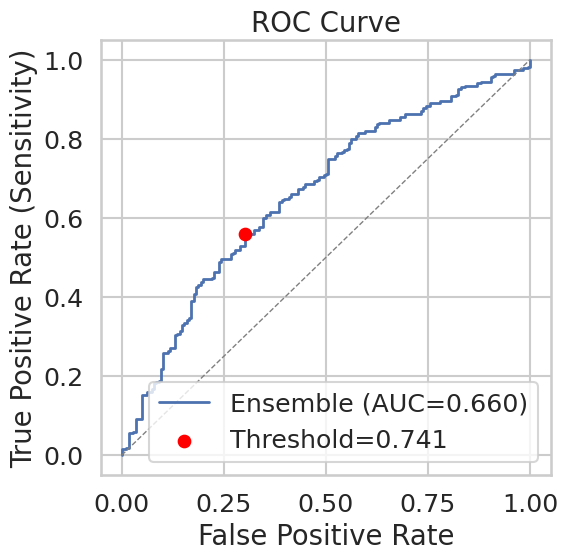

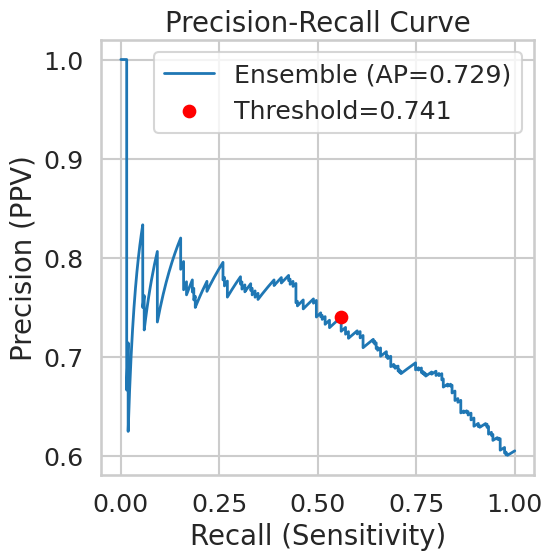

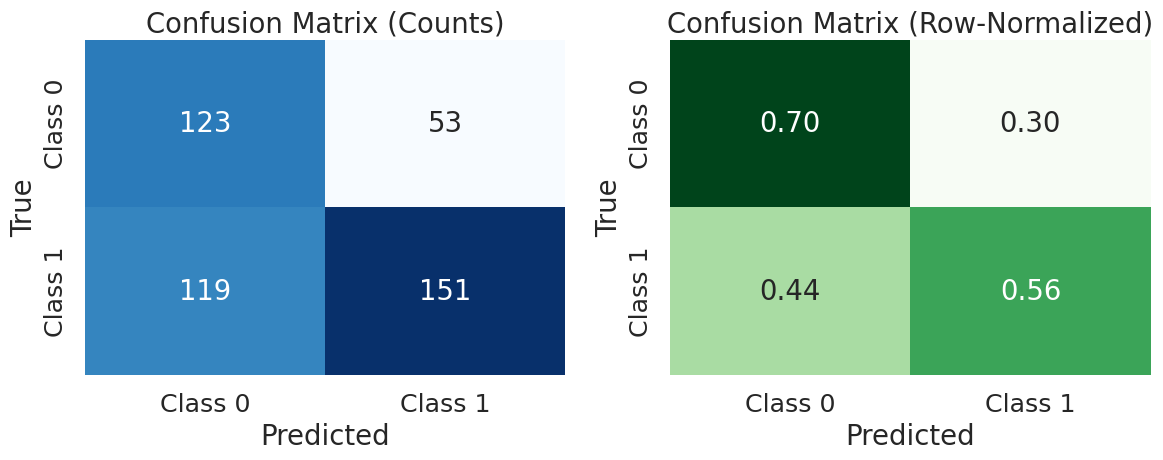

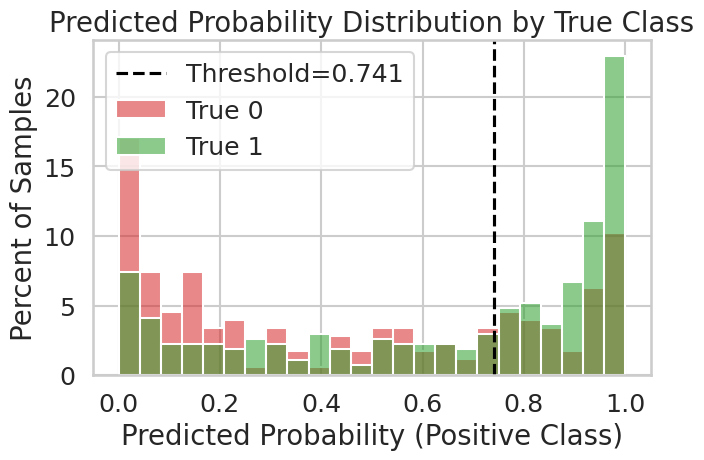

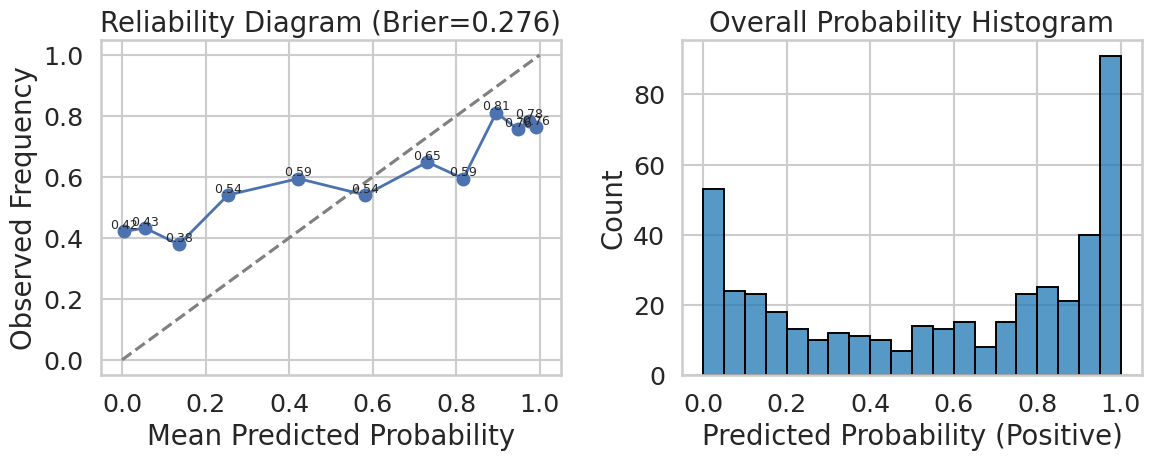

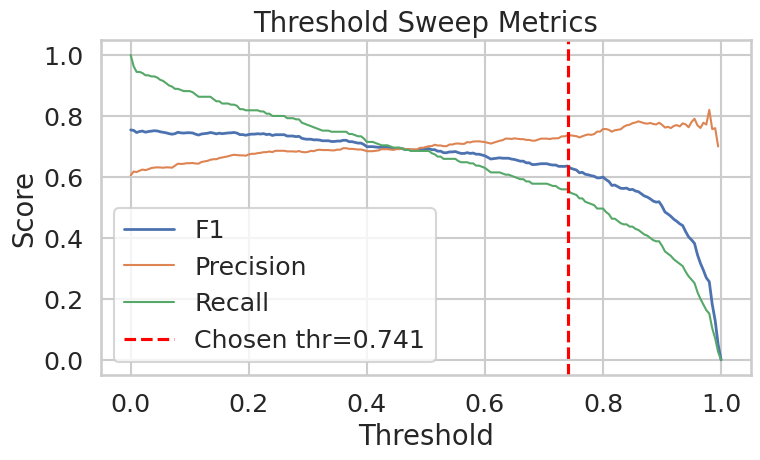

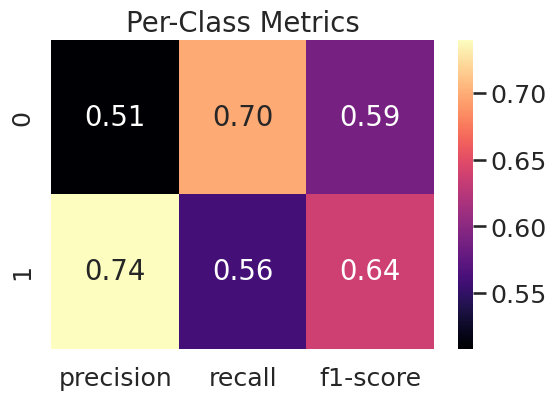

In [14]:
# --- Visualization / Professional Plots ---
import json, os, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
sns.set_theme(style="whitegrid", context="talk", font_scale=1.1)

results_path = output_json  # reuse existing variable
with open(results_path) as f:
    R = json.load(f)

p = np.array(R["probs"])            # shape (N,2)
p_pos = p[:,1]       # shape (N,)


thr = R["threshold"]
cm = np.array(R["confusion_matrix"])
fpr = np.array(R["fpr"])
tpr = np.array(R["tpr"])
prec = np.array(R["precision"])
rec = np.array(R["recall"])
roc_auc = R["roc_auc"]
pr_auc = R["pr_auc"]
weights = R["weights"]
model_paths = R["model_paths"]

fig_dir = os.path.join(os.path.dirname(results_path), "figures")
os.makedirs(fig_dir, exist_ok=True)

# 1. ROC Curve
def plot_roc():
    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f"Ensemble (AUC={roc_auc:.3f})", lw=2)
    plt.plot([0,1],[0,1],'--',color='grey',lw=1)
    # Mark operating point
    # Find closest threshold point to chosen threshold (need thresholds -> recompute)
    from sklearn.metrics import roc_curve
    _fpr,_tpr,_thr = roc_curve(y_true, p_pos)
    idx = np.argmin(np.abs(_thr - thr))
    plt.scatter(_fpr[idx], _tpr[idx], s=70, color='red', zorder=5, label=f"Threshold={thr:.3f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Sensitivity)")
    plt.title("ROC Curve")
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir,"roc_curve.png"), dpi=300)
    plt.show()

# 2. Precision-Recall Curve
def plot_pr():
    plt.figure(figsize=(6,6))
    plt.plot(rec, prec, label=f"Ensemble (AP={pr_auc:.3f})", lw=2, color="#1f77b4")
    # Operating point
    from sklearn.metrics import precision_recall_curve
    _prec,_rec,_thr = precision_recall_curve(y_true, p_pos)
    # _thr has length n-1; align
    idx = np.argmin(np.abs(_thr - thr))
    plt.scatter(_rec[idx], _prec[idx], s=70, color='red', zorder=5, label=f"Threshold={thr:.3f}")
    plt.xlabel("Recall (Sensitivity)")
    plt.ylabel("Precision (PPV)")
    plt.title("Precision-Recall Curve")
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir,"pr_curve.png"), dpi=300)
    plt.show()

# 3. Confusion Matrix (normalized + counts)
def plot_confusion():
    labels = ["Class 0","Class 1"]
    fig, ax = plt.subplots(1,2, figsize=(12,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=labels, yticklabels=labels, ax=ax[0])
    ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("True")
    ax[0].set_title("Confusion Matrix (Counts)")
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens", cbar=False,
                xticklabels=labels, yticklabels=labels, ax=ax[1])
    ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("True")
    ax[1].set_title("Confusion Matrix (Row-Normalized)")
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir,"confusion_matrices.png"), dpi=300)
    plt.show()

# 4. Probability Histograms per class
def plot_prob_hist():
    plt.figure(figsize=(7,5))
    bins = np.linspace(0,1,25)
    sns.histplot(p_pos[y_true==0], bins=bins, color="#d62728", alpha=0.55, label="True 0", stat="percent")
    sns.histplot(p_pos[y_true==1], bins=bins, color="#2ca02c", alpha=0.55, label="True 1", stat="percent")
    plt.axvline(thr, color='black', ls='--', label=f"Threshold={thr:.3f}")
    plt.xlabel("Predicted Probability (Positive Class)")
    plt.ylabel("Percent of Samples")
    plt.title("Predicted Probability Distribution by True Class")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir,"probability_histograms.png"), dpi=300)
    plt.show()

# 5. Calibration / Reliability Diagram + Histogram
def plot_calibration():
    frac_pos, mean_pred = calibration_curve(y_true, p_pos, n_bins=12, strategy="quantile")
    brier = brier_score_loss(y_true, p_pos)
    fig = plt.figure(figsize=(12,5))
    ax1 = plt.subplot(1,2,1)
    ax1.plot([0,1],[0,1],'--',color='gray')
    ax1.plot(mean_pred, frac_pos, marker='o', lw=2)
    for x,y in zip(mean_pred, frac_pos):
        ax1.text(x, y, f"{y:.2f}", fontsize=9, ha='center', va='bottom')
    ax1.set_xlabel("Mean Predicted Probability")
    ax1.set_ylabel("Observed Frequency")
    ax1.set_title(f"Reliability Diagram (Brier={brier:.3f})")
    ax2 = plt.subplot(1,2,2)
    sns.histplot(p_pos, bins=20, color="#1f77b4", edgecolor="black")
    ax2.set_xlabel("Predicted Probability (Positive)")
    ax2.set_ylabel("Count")
    ax2.set_title("Overall Probability Histogram")
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir,"calibration.png"), dpi=300)
    plt.show()

# 6. Threshold sweep (F1, Precision, Recall)
def plot_threshold_sweep():
    from sklearn.metrics import f1_score, precision_score, recall_score
    ts = np.linspace(0,1,201)
    f1s = []; precs = []; recs = []
    for t in ts:
        yp = (p_pos >= t).astype(int)
        if yp.sum()==0:
            precs.append(np.nan)
        else:
            precs.append(precision_score(y_true, yp))
        recs.append(recall_score(y_true, yp))
        f1s.append(f1_score(y_true, yp))
    plt.figure(figsize=(8,5))
    plt.plot(ts, f1s, label="F1", lw=2)
    plt.plot(ts, precs, label="Precision", lw=1.5)
    plt.plot(ts, recs, label="Recall", lw=1.5)
    plt.axvline(thr, color='red', ls='--', label=f"Chosen thr={thr:.3f}")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Threshold Sweep Metrics")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir,"threshold_sweep.png"), dpi=300)
    plt.show()

# 7. Ensemble weight bar plot
def plot_weights():
    if weights and model_paths:
        plt.figure(figsize=(max(6,0.6*len(weights)),5))
        short_names = [os.path.basename(os.path.dirname(os.path.dirname(p)))[:25] for p in model_paths]
        sns.barplot(x=short_names, y=weights, palette="viridis")
        for i,w in enumerate(weights):
            plt.text(i, w+0.005, f"{w:.2f}", ha='center', va='bottom', fontsize=9)
        plt.ylabel("Weight")
        plt.xlabel("Model (Fold)")
        plt.title("Ensemble Weights")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(os.path.join(fig_dir,"ensemble_weights.png"), dpi=300)
        plt.show()

# 8. Classification report table heatmap
def plot_classification_report():
    report = R["classification_report"]
    # Remove overall averages for class heatmap
    class_rows = {k:v for k,v in report.items() if k.isdigit() or k in ["0","1"]}
    import pandas as pd
    df = pd.DataFrame(class_rows).T[["precision","recall","f1-score","support"]]
    fig, ax = plt.subplots(figsize=(6,2.2*len(df)))
    sns.heatmap(df[["precision","recall","f1-score"]].astype(float),
                annot=True, fmt=".2f", cmap="magma", cbar=True, ax=ax)
    ax.set_title("Per-Class Metrics")
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir,"per_class_metrics.png"), dpi=300)
    plt.show()

# Execute all
plot_roc()
plot_pr()
plot_confusion()
plot_prob_hist()
plot_calibration()
plot_threshold_sweep()
plot_weights()
plot_classification_report()

# Using ED and PSA as input for the model

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import joblib

In [16]:
def collect_logits(models, dataloader):
    """Return arrays:
       logits_all: (N, M, 2)
       logit_diff: (N, M)  (pos - neg per model)
       y_true: (N,)
    """
    all_logits = []
    y_true = []
    for batch in dataloader:
        x = batch["image"].to(device)
        # assume label one-hot
        yb = batch["label"]
        if yb.ndim > 1 and yb.shape[1] == 2:
            y_true.append(yb.argmax(1).numpy())
        else:
            y_true.append(yb.numpy())
        per_model = []
        with torch.no_grad():
            for m in models:
                l = m(x)  # (B,2)
                per_model.append(l.cpu().numpy())
        per_model = np.stack(per_model, axis=1)  # (B,M,2)
        all_logits.append(per_model)
    logits_all = np.concatenate(all_logits, axis=0)  # (N,M,2)
    y_true = np.concatenate(y_true)
    logit_diff = logits_all[:,:,1] - logits_all[:,:,0]
    return logits_all, logit_diff, y_true

In [17]:
# Collect test features (will be used AFTER fitting meta-model on OOF)
test_logits_all, test_logit_diff, y_true_test = collect_logits(models, test_dataloader)

In [18]:
test_logits_all.shape

(446, 5, 2)

In [19]:
test_logit_diff.shape

(446, 5)

In [22]:
test_logit_diff[0]

array([ -0.63568294, -21.875124  ,  -2.18667   ,  -2.2129524 ,
        -0.2337529 ], dtype=float32)

In [23]:
test_logits_all[0]

array([[ 0.84112227,  0.20543934],
       [12.010429  , -9.864695  ],
       [ 1.3687917 , -0.8178784 ],
       [ 1.1808188 , -1.0321336 ],
       [-0.0175257 , -0.2512786 ]], dtype=float32)

In [20]:
 #Clinical features: PSA and ED

clinical_features = df_test[['ED','PSA']].values.astype(np.float32)

#combine logit diffs and clinical features
meta_features = np.concatenate([test_logit_diff, clinical_features], axis=1)  # shape (N, M+2)

#Scale features
# scaler = StandardScaler()
# meta_features_scaled = scaler.fit_transform(meta_features)
meta_features_scaled = test_logit_diff#meta_features  # No scaling for simplicity

meta = LogisticRegression(solver='liblinear', max_iter=3000)
# meta = LogisticRegression(max_iter=2000, class_weight="balanced")
meta.fit(meta_features_scaled, y_true_test)

#Meta predictions
meta_probs = meta.predict_proba(meta_features_scaled)  # shape (N,2)

#Meta evaluation
meta_p_pos = meta_probs[:,1]
meta_thr = pick_threshold(y_true_test, meta_p_pos, threshold_mode)
print("Meta chosen threshold:", meta_thr)
meta_y_pred = (meta_p_pos >= meta_thr).astype(int)  

meta_roc_auc = roc_auc_score(y_true_test, meta_p_pos)
meta_fpr, meta_tpr, _ = roc_curve(y_true_test, meta_p_pos)
meta_prec, meta_rec, _ = precision_recall_curve(y_true_test, meta_p_pos)
meta_pr_auc = auc(meta_rec, meta_prec)
meta_report = classification_report(y_true_test, meta_y_pred)
meta_cm = confusion_matrix(y_true_test, meta_y_pred)

print(f"Meta ROC AUC: {meta_roc_auc:.4f}  PR AUC: {meta_pr_auc:.4f}")
print("Meta Confusion matrix:\n", meta_cm)  
print("Meta Classification Report:\n", meta_report)

Meta chosen threshold: 0.5752070636680612
Meta ROC AUC: 0.6902  PR AUC: 0.7534
Meta Confusion matrix:
 [[105  71]
 [ 69 201]]
Meta Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.60      0.60       176
           1       0.74      0.74      0.74       270

    accuracy                           0.69       446
   macro avg       0.67      0.67      0.67       446
weighted avg       0.69      0.69      0.69       446



# Using crossval models

In [ ]:
#With the normal data
# dataloader = Dataloader(path='Files/picai_cv.csv',partition_column="Fold 4")
# test_dataloader = dataloader(partition='test')

Number of partitions: 2
Partitions: dict_keys(['test', 'train'])


Loading dataset: 100%|██████████| 299/299 [00:42<00:00,  7.02it/s]


In [37]:
# --- Configuration ---
fold_model_pattern = "logs/classification/Prostate_Picai_efficientnetb7/18-Aug-2025-10:41:51/models/*/best-model-weights.pth"
cross_val_results_path = "logs/classification/Prostate_Picai_efficientnetb7/18-Aug-2025-10:41:51/cross_val_results.json"
output_json = "outputs/results/ensemble_picai_test_results.json"
use_f1_weights = True          # set False for uniform
apply_platt_after_ensemble = True  # global calibration
threshold_mode = "youden"       # "youden" | "f1" | float value

from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc, classification_report, confusion_matrix, f1_score
import numpy as np, json, os, torch

# --- Load models (already have load_fold_models / ensemble_logits defined above) ---
models, model_paths = load_fold_models(fold_model_pattern)
print(f"Loaded {len(models)} models")



Loaded 5 models


In [42]:
# --- Derive per-fold weights from cross_val_results.json (expects per-fold dicts with Val ROC AUC / or similar) ---
def extract_f1_weights(json_path):
    with open(json_path) as f:
        data = json.load(f)
    f1s = []
    keys = sorted(data.keys())  # fold order
    for k in keys:
        if 'Fold' in k:
            fold_dict = data[k]
            print(f"Fold {k}: {fold_dict['Test Metrics']}")
            f1s.append(fold_dict['Test Metrics']['f1'])
            print(f"Fold {k} F1: {fold_dict['Test Metrics']['f1']}")
            print(f1s)
    f1s = np.array(f1s, dtype=float)
    if (f1s <= 0).any():
        raise ValueError("F1 scores must be positive for weighting.")
    weights = f1s / f1s.sum()
    return weights.tolist()

if use_f1_weights:
    try:
        weights = extract_f1_weights(cross_val_results_path)
    except Exception as e:
        print(f"Falling back to uniform weights ({e})")
        weights = None
else:
    weights = None
print("Weights:", weights)

# --- Run ensemble (no calibration yet) ---
raw_logits, raw_probs = ensemble_logits(models, test_dataloader, weights=weights)
p_pos = raw_probs[:,1]





Fold Fold 0: {'accuracy': 0.7048611044883728, 'f1': 0.6259994506835938}
Fold Fold 0 F1: 0.6259994506835938
[0.6259994506835938]
Fold Fold 1: {'accuracy': 0.774305522441864, 'f1': 0.7763046622276306}
Fold Fold 1 F1: 0.7763046622276306
[0.6259994506835938, 0.7763046622276306]
Fold Fold 2: {'accuracy': 0.711805522441864, 'f1': 0.6375542283058167}
Fold Fold 2 F1: 0.6375542283058167
[0.6259994506835938, 0.7763046622276306, 0.6375542283058167]
Fold Fold 3: {'accuracy': 0.6319444179534912, 'f1': 0.649770975112915}
Fold Fold 3 F1: 0.649770975112915
[0.6259994506835938, 0.7763046622276306, 0.6375542283058167, 0.649770975112915]
Fold Fold 4: {'accuracy': 0.2847222089767456, 'f1': 0.12620119750499725}
Fold Fold 4 F1: 0.12620119750499725
[0.6259994506835938, 0.7763046622276306, 0.6375542283058167, 0.649770975112915, 0.12620119750499725]
Weights: [0.2223143216922629, 0.27569296462036025, 0.2264178277681617, 0.23075642227769416, 0.044818463641521]


In [ ]:
# --- (Optional) Global Platt scaling using out-of-fold (OOF) validation predictions if available ---

def load_oof_predictions(json_path):
    """
    Expect each fold entry to have 'Validation Predictions' (list of [p0,p1]) and maybe 'Validation True Labels'
    If only probabilities exist, we aggregate them.
    """
    with open(json_path) as f:
        data = json.load(f)
    oof_p = []
    oof_y = []
    for fold_name, fold_dict in data.items():
        # predicted probs
        pred_key = None
        for k in ["Validation Predictions","Val Predictions","Val Probabilities","Validation Probabilities"]:
            if k in fold_dict:
                pred_key = k
                break
        if pred_key is None:
            continue
        probs = np.array(fold_dict[pred_key])
        if probs.ndim == 1:  # if only positive class stored
            probs = np.stack([1 - probs, probs], axis=1)
        # true labels
        y_key = None
        for k in ["Validation True Labels","Val True Labels","Validation Labels","Val Labels","y_val"]:
            if k in fold_dict:
                y_key = k
                break
        if y_key is None:
            # cannot calibrate without labels
            continue
        y = np.array(fold_dict[y_key]).astype(int)
        # align length
        n = min(len(y), len(probs))
        oof_p.append(probs[:n])
        oof_y.append(y[:n])
    if not oof_p:
        raise RuntimeError("No OOF validation predictions + labels found for calibration.")
    return np.concatenate(oof_p, axis=0), np.concatenate(oof_y, axis=0)

def platt_fit(probs, labels):
    # convert probs -> logit diff z
    p1 = np.clip(probs[:,1], 1e-6, 1-1e-6)
    z = np.log(p1/(1-p1))
    y = labels.astype(float)
    from scipy.optimize import minimize
    def nll(params):
        a, b = params
        s = a*z + b
        pp = 1/(1+np.exp(-s))
        eps=1e-7
        return -np.mean(y*np.log(np.clip(pp,eps,1-eps)) + (1-y)*np.log(np.clip(1-pp,eps,1-eps)))
    res = minimize(nll, [1.0,0.0], method="L-BFGS-B")
    return res.x  # a,b

def platt_apply(probs, params):
    a,b = params
    p1 = np.clip(probs[:,1], 1e-6, 1-1e-6)
    z = np.log(p1/(1-p1))
    s = a*z + b
    p1c = 1/(1+np.exp(-s))
    p0c = 1-p1c
    return np.stack([p0c, p1c], axis=1)

if apply_platt_after_ensemble:
    try:
        oof_probs, oof_labels = load_oof_predictions(cross_val_results_path)
        # Simulate ensemble for OOF samples:
        # If you want true ensemble OOF logits you must store per-model OOF outputs; here we calibrate on averaged probs approximation.
        platt_params = platt_fit(oof_probs, oof_labels)
        print("Platt params:", platt_params)
        calib_probs = platt_apply(raw_probs, platt_params)
    except Exception as e:
        print(f"Platt scaling skipped ({e})")
        calib_probs = raw_probs
else:
    calib_probs = raw_probs

p_pos_cal = calib_probs[:,1]

# --- Threshold selection ---
def pick_threshold(y_true, p_pos, mode="youden"):
    if isinstance(mode,(float,int)):
        return float(mode)
    fpr, tpr, thr = roc_curve(y_true, p_pos)
    if mode == "youden":
        j = tpr - fpr
        return thr[np.argmax(j)]
    if mode == "f1":
        best_t, best_f1 = 0.5, -1
        for t in thr:
            pred = (p_pos >= t).astype(int)
            f1v = f1_score(y_true, pred)
            if f1v > best_f1:
                best_f1, best_t = f1v, t
        return best_t
    return 0.5

Platt scaling skipped (No OOF validation predictions + labels found for calibration.)


In [43]:
# --- Collect true labels from test_dataloader ---
y_true = []
for batch in test_dataloader:
    yb = batch["label"]
    if yb.ndim > 1 and yb.shape[1] == 2:  # one-hot
        yb = yb.argmax(1)
    y_true.append(yb.numpy())
y_true = np.concatenate(y_true)

thr = pick_threshold(y_true, p_pos, threshold_mode)
print("Chosen threshold:", thr)

y_pred = (p_pos >= thr).astype(int)

# --- Metrics ---
roc_auc = roc_auc_score(y_true, p_pos)
fpr, tpr, _ = roc_curve(y_true, p_pos)
prec, rec, _ = precision_recall_curve(y_true, p_pos)
pr_auc = auc(rec, prec)
report = classification_report(y_true, y_pred, output_dict=True)
cm = confusion_matrix(y_true, y_pred)

print(f"ROC AUC: {roc_auc:.4f}  PR AUC: {pr_auc:.4f}")
print("Confusion matrix:\n", cm)

# --- Save results ---
results = {
    "model_paths": model_paths,
    "weights": weights,
    "platt_params": (platt_params.tolist() if apply_platt_after_ensemble and 'platt_params' in locals() else None),
    "threshold": float(thr),
    "roc_auc": float(roc_auc),
    "pr_auc": float(pr_auc),
    "fpr": fpr.tolist(),
    "tpr": tpr.tolist(),
    "precision": prec.tolist(),
    "recall": rec.tolist(),
    "classification_report": report,
    "confusion_matrix": cm.tolist(),
    "probs": calib_probs.tolist()
}
os.makedirs(os.path.dirname(output_json), exist_ok=True)
with open(output_json, "w") as f:
    json.dump(results, f, indent=2)
print("Saved:", output_json)

Chosen threshold: 0.40166312
ROC AUC: 0.9537  PR AUC: 0.9323
Confusion matrix:
 [[198  17]
 [  8  76]]
Saved: /home/ceib/jaalzate/BIMCV-Prostate-Classification/outputs/results/ensemble_picai_test_results.json


In [46]:
y_pred.shape

(299,)

In [47]:
y_true.shape

(299,)

ValueError: Found input variables with inconsistent numbers of samples: [299, 298]

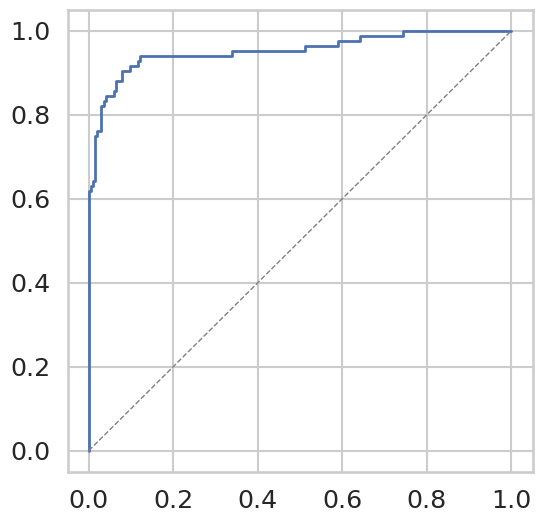

In [48]:
# --- Visualization / Professional Plots ---
import json, os, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
sns.set_theme(style="whitegrid", context="talk", font_scale=1.1)

results_path = output_json  # reuse existing variable
with open(results_path) as f:
    R = json.load(f)

p = np.array(R["probs"])            # shape (N,2)
p_pos = p[:298,1]


thr = R["threshold"]
cm = np.array(R["confusion_matrix"])
fpr = np.array(R["fpr"])
tpr = np.array(R["tpr"])
prec = np.array(R["precision"])
rec = np.array(R["recall"])
roc_auc = R["roc_auc"]
pr_auc = R["pr_auc"]
weights = R["weights"]
model_paths = R["model_paths"]

fig_dir = os.path.join(os.path.dirname(results_path), "figures")
os.makedirs(fig_dir, exist_ok=True)

# 1. ROC Curve
def plot_roc():
    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f"Ensemble (AUC={roc_auc:.3f})", lw=2)
    plt.plot([0,1],[0,1],'--',color='grey',lw=1)
    # Mark operating point
    # Find closest threshold point to chosen threshold (need thresholds -> recompute)
    from sklearn.metrics import roc_curve
    _fpr,_tpr,_thr = roc_curve(y_true, p_pos)
    idx = np.argmin(np.abs(_thr - thr))
    plt.scatter(_fpr[idx], _tpr[idx], s=70, color='red', zorder=5, label=f"Threshold={thr:.3f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Sensitivity)")
    plt.title("ROC Curve")
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir,"roc_curve.png"), dpi=300)
    plt.show()

# 2. Precision-Recall Curve
def plot_pr():
    plt.figure(figsize=(6,6))
    plt.plot(rec, prec, label=f"Ensemble (AP={pr_auc:.3f})", lw=2, color="#1f77b4")
    # Operating point
    from sklearn.metrics import precision_recall_curve
    _prec,_rec,_thr = precision_recall_curve(y_true, p_pos)
    # _thr has length n-1; align
    idx = np.argmin(np.abs(_thr - thr))
    plt.scatter(_rec[idx], _prec[idx], s=70, color='red', zorder=5, label=f"Threshold={thr:.3f}")
    plt.xlabel("Recall (Sensitivity)")
    plt.ylabel("Precision (PPV)")
    plt.title("Precision-Recall Curve")
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir,"pr_curve.png"), dpi=300)
    plt.show()

# 3. Confusion Matrix (normalized + counts)
def plot_confusion():
    labels = ["Class 0","Class 1"]
    fig, ax = plt.subplots(1,2, figsize=(12,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=labels, yticklabels=labels, ax=ax[0])
    ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("True")
    ax[0].set_title("Confusion Matrix (Counts)")
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens", cbar=False,
                xticklabels=labels, yticklabels=labels, ax=ax[1])
    ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("True")
    ax[1].set_title("Confusion Matrix (Row-Normalized)")
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir,"confusion_matrices.png"), dpi=300)
    plt.show()

# 4. Probability Histograms per class
def plot_prob_hist():
    plt.figure(figsize=(7,5))
    bins = np.linspace(0,1,25)
    sns.histplot(p_pos[y_true==0], bins=bins, color="#d62728", alpha=0.55, label="True 0", stat="percent")
    sns.histplot(p_pos[y_true==1], bins=bins, color="#2ca02c", alpha=0.55, label="True 1", stat="percent")
    plt.axvline(thr, color='black', ls='--', label=f"Threshold={thr:.3f}")
    plt.xlabel("Predicted Probability (Positive Class)")
    plt.ylabel("Percent of Samples")
    plt.title("Predicted Probability Distribution by True Class")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir,"probability_histograms.png"), dpi=300)
    plt.show()

# 5. Calibration / Reliability Diagram + Histogram
def plot_calibration():
    frac_pos, mean_pred = calibration_curve(y_true, p_pos, n_bins=12, strategy="quantile")
    brier = brier_score_loss(y_true, p_pos)
    fig = plt.figure(figsize=(12,5))
    ax1 = plt.subplot(1,2,1)
    ax1.plot([0,1],[0,1],'--',color='gray')
    ax1.plot(mean_pred, frac_pos, marker='o', lw=2)
    for x,y in zip(mean_pred, frac_pos):
        ax1.text(x, y, f"{y:.2f}", fontsize=9, ha='center', va='bottom')
    ax1.set_xlabel("Mean Predicted Probability")
    ax1.set_ylabel("Observed Frequency")
    ax1.set_title(f"Reliability Diagram (Brier={brier:.3f})")
    ax2 = plt.subplot(1,2,2)
    sns.histplot(p_pos, bins=20, color="#1f77b4", edgecolor="black")
    ax2.set_xlabel("Predicted Probability (Positive)")
    ax2.set_ylabel("Count")
    ax2.set_title("Overall Probability Histogram")
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir,"calibration.png"), dpi=300)
    plt.show()

# 6. Threshold sweep (F1, Precision, Recall)
def plot_threshold_sweep():
    from sklearn.metrics import f1_score, precision_score, recall_score
    ts = np.linspace(0,1,201)
    f1s = []; precs = []; recs = []
    for t in ts:
        yp = (p_pos >= t).astype(int)
        if yp.sum()==0:
            precs.append(np.nan)
        else:
            precs.append(precision_score(y_true, yp))
        recs.append(recall_score(y_true, yp))
        f1s.append(f1_score(y_true, yp))
    plt.figure(figsize=(8,5))
    plt.plot(ts, f1s, label="F1", lw=2)
    plt.plot(ts, precs, label="Precision", lw=1.5)
    plt.plot(ts, recs, label="Recall", lw=1.5)
    plt.axvline(thr, color='red', ls='--', label=f"Chosen thr={thr:.3f}")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Threshold Sweep Metrics")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir,"threshold_sweep.png"), dpi=300)
    plt.show()

# 7. Ensemble weight bar plot
def plot_weights():
    if weights and model_paths:
        plt.figure(figsize=(max(6,0.6*len(weights)),5))
        short_names = [os.path.basename(os.path.dirname(os.path.dirname(p)))[:25] for p in model_paths]
        sns.barplot(x=short_names, y=weights, palette="viridis")
        for i,w in enumerate(weights):
            plt.text(i, w+0.005, f"{w:.2f}", ha='center', va='bottom', fontsize=9)
        plt.ylabel("Weight")
        plt.xlabel("Model (Fold)")
        plt.title("Ensemble Weights")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(os.path.join(fig_dir,"ensemble_weights.png"), dpi=300)
        plt.show()

# 8. Classification report table heatmap
def plot_classification_report():
    report = R["classification_report"]
    # Remove overall averages for class heatmap
    class_rows = {k:v for k,v in report.items() if k.isdigit() or k in ["0","1"]}
    import pandas as pd
    df = pd.DataFrame(class_rows).T[["precision","recall","f1-score","support"]]
    fig, ax = plt.subplots(figsize=(6,2.2*len(df)))
    sns.heatmap(df[["precision","recall","f1-score"]].astype(float),
                annot=True, fmt=".2f", cmap="magma", cbar=True, ax=ax)
    ax.set_title("Per-Class Metrics")
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir,"per_class_metrics.png"), dpi=300)
    plt.show()

# Execute all
plot_roc()
plot_pr()
plot_confusion()
plot_prob_hist()
plot_calibration()
plot_threshold_sweep()
plot_weights()
plot_classification_report()
